<a href="https://colab.research.google.com/github/rioAgustian/pytorch_deep_learning/blob/main/01_pytorch_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install

ERROR: You must give at least one requirement to install (see "pip help install")


## MNIST data setup

In [2]:
from pathlib import Path
import requests

DATA_PATH = Path("data")
PATH = DATA_PATH / "mnist"

PATH.mkdir(parents=True, exist_ok=True)

URL = "https://github.com/pytorch/tutorials/raw/main/_static/"
FILENAME = "mnist.pkl.gz"

if not (PATH / FILENAME).exists():
  content = requests.get(URL + FILENAME).content
  (PATH / FILENAME).open("wb").write(content)

In [3]:
import pickle
import gzip

with gzip.open((PATH /FILENAME).as_posix(), "rb") as f:
  ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding="latin-1")

(50000, 784)


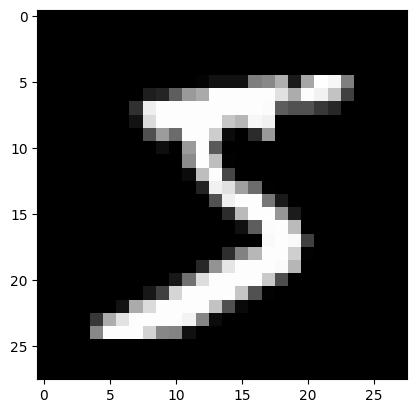

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(x_train[0].reshape((28, 28)), cmap="gray")

try:
  import google.colab
except ImportError:
  plt.show()
print(x_train.shape)

In [5]:
import torch

x_train, y_train, x_valid, y_valid = map(
    torch.tensor, (x_train, y_train, x_valid, y_valid)
)
n, c = x_train.shape
print(x_train, y_train)
print(x_train.shape)
print(y_train.min(), y_train.max())

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
torch.Size([50000, 784])
tensor(0) tensor(9)


## Neural net from scratch (without torch.nn)

In [6]:
import math

weights = torch.randn(784, 10) / math.sqrt(784)
weights.requires_grad_()
bias = torch.zeros(10, requires_grad=True)

In [7]:
def log_softmax(x):
  return x - x.exp().sum(-1).log().unsqueeze(-1)

def model(xb):
  return log_softmax(xb @ weights + bias)

In [8]:
bs = 64
xb = x_train[0:bs]
preds = model(xb)
preds[0], preds.shape

(tensor([-1.7472, -2.0651, -3.2036, -2.4054, -3.4694, -2.2677, -2.3898, -2.3149,
         -2.1130, -2.1030], grad_fn=<SelectBackward0>),
 torch.Size([64, 10]))

In [9]:
def nll(input, target):
  return -input[range(target.shape[0]), target].mean()

loss_func = nll

In [10]:
yb = y_train[0:bs]
print(loss_func(preds, yb))

tensor(2.3884, grad_fn=<NegBackward0>)


In [11]:
def accuracy(out, yb):
  preds = torch.argmax(out, dim=1)
  return (preds == yb).float().mean()

In [12]:
print(accuracy(preds, yb))

tensor(0.1094)


In [13]:
from IPython.core.debugger import set_trace

lr = 0.5
epochs = 2

for epoch in range(epochs):
  for i in range((n-1) // bs + 1):
    start_i = i * bs
    end_i = start_i + bs
    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]
    pred = model(xb)
    loss = loss_func(pred, yb)

    loss.backward()
    with torch.no_grad():
      weights -= weights.grad * lr
      bias -= bias.grad * lr
      weights.grad.zero_()
      bias.grad.zero_()

In [14]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0816, grad_fn=<NegBackward0>) tensor(1.)


## Using `torch.nn.functional`

In [15]:
import torch.nn.functional as F

loss_func = F.cross_entropy

def model(xb):
  return xb @ weights + bias

In [16]:
print(loss_func(model(xb), yb), accuracy(model(xb), yb))

tensor(0.0816, grad_fn=<NllLossBackward0>) tensor(1.)


## Refactor using `nn.Module`

In [17]:
from torch import nn

class Mnist_Logistic(nn.Module):
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(torch.randn(784, 10) / math.sqrt(784))
    self.bias = nn.Parameter(torch.zeros(10))

  def forward(self, xb):
    return xb @ self.weights + self.bias

In [18]:
model = Mnist_Logistic()

In [19]:
print(loss_func(model(xb), yb))

tensor(2.2201, grad_fn=<NllLossBackward0>)


In [20]:
with torch.no_grad():
  weights -= weights.grad * lr
  bias -= bias.grad * lr
  weights.grad.zero_()
  bias.grad.zero_()

In [21]:
def fit():
  for epoch in range(epochs):
    for i in range((n - 1) // bs + 1):
      start_i = i * bs
      end_i = start_i + bs
      xb = x_train[start_i:end_i]
      yb = y_train[start_i:end_i]
      pred = model(xb)
      loss = loss_func(pred, yb)

      loss.backward()
      with torch.no_grad():
        for p in model.parameters():
          p -= p.grad * lr
        model.zero_grad()

fit()

In [22]:
print(loss_func(model(xb), yb))

tensor(0.0816, grad_fn=<NllLossBackward0>)


## Refractor using `nn.Linear`

In [23]:
class Mnist_Logistic(nn.Module):
  def __init__(self):
    super().__init__()
    self.lin = nn.Linear(784, 10)

  def forward(self, xb):
    return self.lin(xb)

In [24]:
model = Mnist_Logistic()
print(loss_func(model(xb), yb))

tensor(2.1912, grad_fn=<NllLossBackward0>)


In [25]:
fit()
print(loss_func(model(xb), yb))

tensor(0.0807, grad_fn=<NllLossBackward0>)



## Refractor using `torch.optim`

In [26]:
from torch import optim

def get_model():
  model = Mnist_Logistic()
  return model, optim.SGD(model.parameters(), lr=lr)

model, opt = get_model()
print(loss_func(model(xb), yb))

for epoch in range(epochs):
  for i in range((n - 1) // bs + 1):
    start_i = i * bs
    end_i = start_i + bs
    xb = x_train[start_i:end_i]
    yb = y_train[start_i:end_i]
    pred = model(xb)
    loss = loss_func(pred, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(2.3185, grad_fn=<NllLossBackward0>)
tensor(0.0840, grad_fn=<NllLossBackward0>)


## Refractor using Dataset

In [27]:
from torch.utils.data import TensorDataset

In [28]:
train_ds = TensorDataset(x_train, y_train)

In [29]:
xb = x_train[start_i:end_i]
yb = y_train[start_i:end_i]

In [30]:
xb, yb = train_ds[i*bs : i*bs+bs]

In [31]:
model, opt = get_model()

for epoch in range(epochs):
  for i in range((n - 1) // bs + 1):
    xb, yb = train_ds[i * bs: i * bs + bs]
    pred = model(xb)
    loss = loss_func(pred, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0811, grad_fn=<NllLossBackward0>)


## Refractor using DataLoader

In [32]:
from torch.utils.data import DataLoader

train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs)

In [33]:
for i in range((n - 1) // bs + 1):
  xb, yb = train_ds[i*bs : i*bs+bs]
  pred = model(xb)

In [34]:
for xb, yb in train_dl:
  pred = model(xb)

In [35]:
model, opt = get_model()

for epoch in range(epochs):
  for xb, yb in train_dl:
    pred = model(xb)
    loss = loss_func(pred, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

print(loss_func(model(xb), yb))

tensor(0.0819, grad_fn=<NllLossBackward0>)


## Add validation

In [36]:
train_ds = TensorDataset(x_train, y_train)
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)

valid_ds = TensorDataset(x_valid, y_valid)
valid_dl = DataLoader(valid_ds, batch_size=bs * 2)

In [37]:
model, opt = get_model()

for epoch in range(epochs):
  model.train()
  for xb, yb in train_dl:
    pred = model(xb)
    loss = loss_func(pred, yb)

    loss.backward()
    opt.step()
    opt.zero_grad()

  model.eval()
  with torch.no_grad():
    valid_loss = sum(loss_func(model(xb), yb) for xb, yb in valid_dl)

  print(epoch, valid_loss / len(valid_dl))

0 tensor(0.3092)
1 tensor(0.2891)


## Create `fit()` and `get_data()`

In [38]:
def loss_batch(model, loss_func, xb, yb, opt=None):
  loss = loss_func(model(xb), yb)

  if opt is not None:
    loss.backward()
    opt.step()
    opt.zero_grad()

  return loss.item(), len(xb)

In [39]:
import numpy as np

def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
  for epoch in range(epochs):
    model.train()
    for xb, yb in train_dl:
      loss_batch(model, loss_func, xb, yb, opt)

    model.eval()
    with torch.no_grad():
      losses, nums = zip (
          *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
      )
    val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums)

    print(epoch, val_loss)

In [40]:
def get_data(trarin_ds, valid_ds, bs):
  return(
      DataLoader(train_ds, batch_size=bs, shuffle=True),
      DataLoader(valid_ds, batch_size=bs * 2)
  )

In [41]:
train_dl, train_dl = get_data(train_ds, valid_ds, bs)
model, opt = get_model()
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.3977754123091698
1 0.3383455510020256


## Switch to CNN

In [42]:
class Mnist_CNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1,  16, kernel_size=3, stride=2, padding=1)
    self.conv2 = nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1)
    self.conv3 = nn.Conv2d(16, 10, kernel_size=3, stride=2, padding=1)

  def forward(self, xb):
    xb = xb.view(-1, 1, 28, 28)
    xb = F.relu(self.conv1(xb))
    xb = F.relu(self.conv2(xb))
    xb = F.relu(self.conv3(xb))
    xb = F.avg_pool2d(xb, 4)
    return xb.view(-1, xb.size(1))

lr = 0.1

In [43]:
model = Mnist_CNN()
opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 2.1591299884796142
1 1.3695769550323487


## Using `nn.Sequential`

In [44]:
class Lambda(nn.Module):
  def __init__(self, func):
    super().__init__()
    self.func = func

  def forward(self, x):
    return self.func(x)

def preprocess(x):
  return x.view(-1, 1, 28, 28)

In [45]:
model = nn.Sequential(
    Lambda(preprocess),
    nn.Conv2d(1,  16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1),
    nn.Conv2d(16, 10, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(4),
    Lambda(lambda x: x.view(x.size(0), -1)),
)

opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 2.0205207822799682
1 1.1153626993179322


## Wrapping `DataLoader`

In [46]:
def preprocess(x, y):
  return x.view(-1, 1, 28, 28), y

class WrappedDataLoader:
  def __init__(self, dl, func):
    self.dl = dl
    self.func = func

  def __len__(self):
    return len(self.dl)

  def __iter__(self):
    for b in self.dl:
      yield (self.func(*b))

train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
train_dl = WrappedDataLoader(train_dl, preprocess)
valid_dl = WrappedDataLoader(valid_dl, preprocess)

In [47]:
model = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 16, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.Conv2d(16, 10, kernel_size=3, stride=2, padding=1),
    nn.ReLU(),
    nn.AdaptiveAvgPool2d(1),
    Lambda(lambda x: x.view(x.size(0), -1)),
)

opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [48]:
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.47006152119636535
1 0.24323353486061097


## Using your Accelerator

In [49]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [51]:
def preprocess(x, y):
  return x.view(-1, 1, 28, 28).to(device), y.to(device)

train_dl, valid_dl = get_data(train_ds, valid_ds, bs)
train_dl = WrappedDataLoader(train_dl, preprocess)
valid_dl = WrappedDataLoader(valid_dl, preprocess)

In [52]:
model.to(device)
opt = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

In [53]:
fit(epochs, model, loss_func, opt, train_dl, valid_dl)

0 0.20379110174179077
1 0.2056444058418274
